In [1]:
import pandas as pd 
import numpy as np

In [2]:
df_train=pd.read_csv(r'C:/Users/HP/Downloads/train_world_cup.csv')
df_train.head

<bound method NDFrame.head of      version           team      continent  is_host  goals_scored_last_4y  \
0       2006         Angola         Africa        0                    61   
1       2006      Argentina  South America        0                    97   
2       2006      Australia        Oceania        0                   101   
3       2006         Brazil  South America        0                   117   
4       2006     Costa Rica  North America        0                    89   
..       ...            ...            ...      ...                   ...   
187     2002         Sweden         Europe        0                    64   
188     2002        Tunisia         Africa        0                    85   
189     2002         Turkey         Europe        0                    46   
190     2002  United States  North America        0                    91   
191     2002        Uruguay  South America        0                    56   

     goals_received_last_4y  wins_last_4y  lo

In [3]:
df_train.info()
df_train.describe(include='all')
print(df_train.shape)

<class 'pandas.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   version                          192 non-null    int64  
 1   team                             192 non-null    str    
 2   continent                        192 non-null    str    
 3   is_host                          192 non-null    int64  
 4   goals_scored_last_4y             192 non-null    int64  
 5   goals_received_last_4y           192 non-null    int64  
 6   wins_last_4y                     192 non-null    int64  
 7   losses_last_4y                   192 non-null    int64  
 8   draws_last_4y                    192 non-null    int64  
 9   world_cup_titles_before          192 non-null    int64  
 10  squad_total_market_value_eur     160 non-null    float64
 11  fifa_rank_pre_tournament         192 non-null    int64  
 12  fifa_points_pre_tournament       

In [4]:
df_train.isnull().sum().sort_values(ascending=False)

squad_total_market_value_eur       32
version                             0
squad_avg_age                       0
semi_finalist                       0
finalist                            0
winner                              0
finals_before                       0
semifinals_before                   0
quarterfinals_before                0
round16_before                      0
groups_passed_before                0
world_cup_participations_before     0
fifa_points_pre_tournament          0
team                                0
fifa_rank_pre_tournament            0
world_cup_titles_before             0
draws_last_4y                       0
losses_last_4y                      0
wins_last_4y                        0
goals_received_last_4y              0
goals_scored_last_4y                0
is_host                             0
continent                           0
quarter_finalist                    0
dtype: int64

In [5]:
#handle missing values
df_train['squad_total_market_value_eur']=df_train['squad_total_market_value_eur'].fillna(df_train['squad_total_market_value_eur'].median())

In [6]:
df_train.isna().sum()

version                            0
team                               0
continent                          0
is_host                            0
goals_scored_last_4y               0
goals_received_last_4y             0
wins_last_4y                       0
losses_last_4y                     0
draws_last_4y                      0
world_cup_titles_before            0
squad_total_market_value_eur       0
fifa_rank_pre_tournament           0
fifa_points_pre_tournament         0
squad_avg_age                      0
world_cup_participations_before    0
groups_passed_before               0
round16_before                     0
quarterfinals_before               0
semifinals_before                  0
finals_before                      0
winner                             0
finalist                           0
semi_finalist                      0
quarter_finalist                   0
dtype: int64

In [7]:
#Encode categorical variables
#The categorical columns are likely 'team' and 'continent'
from sklearn.preprocessing import LabelEncoder
le_team=LabelEncoder()
le_continent=LabelEncoder()
df_train['team']=le_team.fit_transform(df_train['team'])
df_train['continent']=le_team.fit_transform(df_train['continent'])

In [8]:
#create X and y
X=df_train.drop(["winner","finalist","semi_finalist","quarter_finalist"],axis=1)
y=df_train['winner']

In [9]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [10]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=500,random_state=42,max_depth=None)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [11]:
#Evaluate Random Forest
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.9743589743589743
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        38
           1       0.00      0.00      0.00         1

    accuracy                           0.97        39
   macro avg       0.49      0.50      0.49        39
weighted avg       0.95      0.97      0.96        39



C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [13]:
#XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=500,learning_rate=0.03,max_depth=5,random_state=42,eval_metric="logloss")

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))

Accuracy: 0.9487179487179487


In [35]:
#predicting on new data 
new_team = {
    "version": 2026,
    "team": 1,
    "continent": 0,
    "is_host": 0,
    "goals_scored_last_4y": 65,
    "goals_received_last_4y": 20,
    "wins_last_4y": 35,
    "losses_last_4y": 5,
    "draws_last_4y": 8,
    "world_cup_titles_before": 3,
    "squad_total_market_value_eur": 1200000000,
    "fifa_rank_pre_tournament": 1,
    "fifa_points_pre_tournament": 1850,
    "squad_avg_age": 27.2,
    "world_cup_participations_before": 18,
    "groups_passed_before": 14,
    "round16_before": 10,
    "quarterfinals_before": 6,
    "semifinals_before": 5,
    "finals_before": 3
}

new_data = pd.DataFrame([new_team])

prediction = rf.predict(new_data)

if prediction == 0:
    print("Predicted: World Cup Winner")
else:
    print("Predicted: Not Winner")

Predicted: World Cup Winner


In [37]:
prob = rf.predict_proba(new_data)
print(prob)

[[0.614 0.386]]


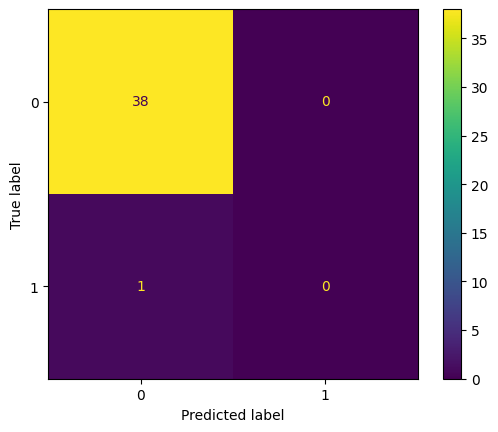

In [38]:
#Create the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# predictions on test set
y_pred = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf.classes_
)

disp.plot()
plt.show()